Original Columns:
Index(['Month', '#Passengers'], dtype='object')

First 5 Rows:
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121

Columns After Renaming:
Index(['Month', 'Passengers'], dtype='object')

Data After Setting Date as Index:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None

Dataset Shape:
(144, 1)

Statistical Summary:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.

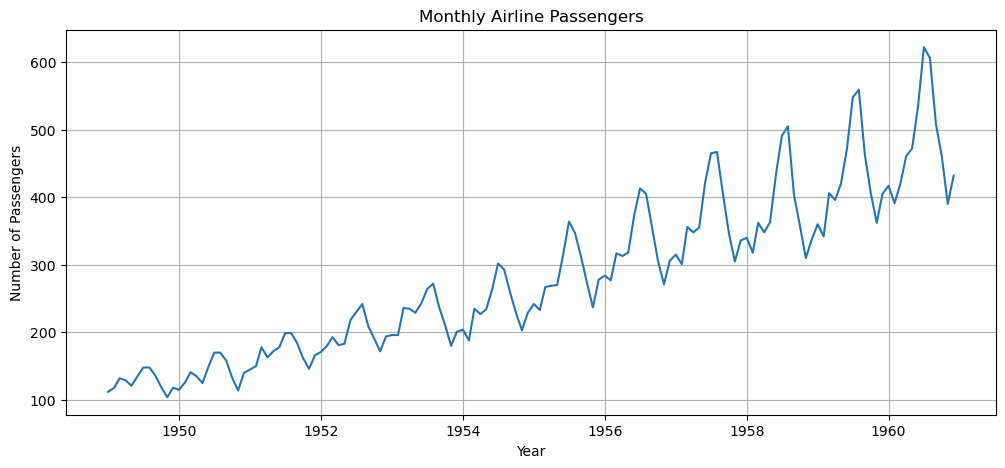


ADF TEST - ORIGINAL DATA
ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641
Result: Non-Stationary

Data After First Differencing:
            Passengers  Diff1
Month                        
1949-01-01         112    NaN
1949-02-01         118    6.0
1949-03-01         132   14.0
1949-04-01         129   -3.0
1949-05-01         121   -8.0

ADF TEST - AFTER FIRST DIFFERENCING
ADF Statistic: -2.8292668241699905
p-value: 0.05421329028382671
Result: Non-Stationary


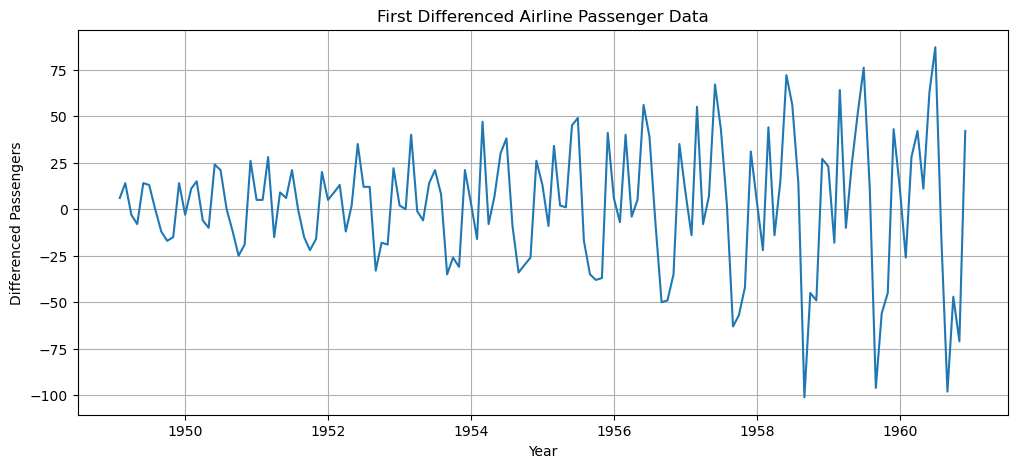


TRAIN-TEST SPLIT
Training Data Size: 115
Testing Data Size: 29

Training Period:
1949-01-01 00:00:00 to 1958-07-01 00:00:00

Testing Period:
1958-08-01 00:00:00 to 1960-12-01 00:00:00

ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -526.123
Date:                Sat, 26 Sep 2026   AIC                           1058.246
Time:                        14:00:14   BIC                           1066.454
Sample:                    01-01-1949   HQIC                          1061.577
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


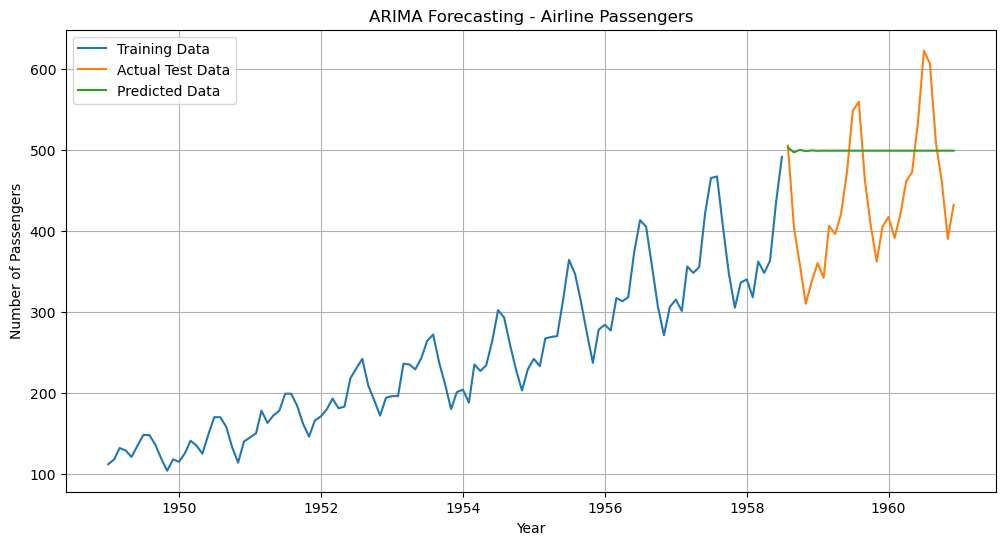

In [9]:


# ==========================================
# EX6B: TIME SERIES DATA ANALYSIS AND FORECAST
# Airline Passenger Dataset - ARIMA
# ==========================================


# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error


# ==========================================
# 2. LOAD KAGGLE DATASET
# ==========================================

df = pd.read_csv(r"C:\Users\REC\Downloads\archive (1)\AirPassengers.csv")

print("Original Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())


# ==========================================
# 3. RENAME COLUMNS
# ==========================================

# Rename the passenger column
df.columns = ["Month", "Passengers"]

print("\nColumns After Renaming:")
print(df.columns)


# ==========================================
# 4. CONVERT MONTH TO DATETIME
# ==========================================

df["Month"] = pd.to_datetime(df["Month"])

# Make Month the index
df.set_index("Month", inplace=True)

print("\nData After Setting Date as Index:")
print(df.head())


# ==========================================
# 5. EXPLORE DATASET
# ==========================================

print("\nDataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================
# 6. PLOT ORIGINAL TIME SERIES
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(df["Passengers"])

plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.grid()
plt.show()


# ==========================================
# 7. ADF STATIONARITY TEST
# ==========================================

def adf_test(data):

    result = adfuller(data)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-Stationary")


print("\n===================================")
print("ADF TEST - ORIGINAL DATA")
print("===================================")

adf_test(df["Passengers"])


# ==========================================
# 8. FIRST DIFFERENCING
# ==========================================

df["Diff1"] = df["Passengers"].diff()

print("\nData After First Differencing:")
print(df.head())


# Remove NaN value
diff1 = df["Diff1"].dropna()


# ==========================================
# 9. ADF TEST AFTER DIFFERENCING
# ==========================================

print("\n===================================")
print("ADF TEST - AFTER FIRST DIFFERENCING")
print("===================================")

adf_test(diff1)


# ==========================================
# 10. PLOT DIFFERENCED DATA
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(diff1)

plt.title("First Differenced Airline Passenger Data")
plt.xlabel("Year")
plt.ylabel("Differenced Passengers")

plt.grid()
plt.show()


# ==========================================
# 11. TRAIN-TEST SPLIT
# ==========================================

passengers = df["Passengers"]

# 80% training
train_size = int(len(passengers) * 0.80)

train = passengers.iloc[:train_size]
test = passengers.iloc[train_size:]

print("\n===================================")
print("TRAIN-TEST SPLIT")
print("===================================")

print("Training Data Size:", len(train))
print("Testing Data Size:", len(test))

print("\nTraining Period:")
print(train.index[0], "to", train.index[-1])

print("\nTesting Period:")
print(test.index[0], "to", test.index[-1])


# ==========================================
# 12. BUILD ARIMA MODEL
# ==========================================

# ARIMA(p,d,q)
# p = 1
# d = 1
# q = 1

model = ARIMA(
    train,
    order=(1, 1, 1)
)

model_fit = model.fit()


print("\n===================================")
print("ARIMA MODEL SUMMARY")
print("===================================")

print(model_fit.summary())


# ==========================================
# 13. FORECAST
# ==========================================

forecast = model_fit.forecast(
    steps=len(test)
)

print("\n===================================")
print("FORECASTED VALUES")
print("===================================")

print(forecast)


# ==========================================
# 14. EVALUATION METRICS
# ==========================================

mse = mean_squared_error(
    test,
    forecast
)

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(mse)


print("\n===================================")
print("EVALUATION METRICS")
print("===================================")

print("MSE  :", mse)
print("MAE  :", mae)
print("RMSE :", rmse)


# ==========================================
# 15. FINAL PLOT
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    train,
    label="Training Data"
)

plt.plot(
    test,
    label="Actual Test Data"
)

plt.plot(
    test.index,
    forecast,
    label="Predicted Data"
)

plt.title("ARIMA Forecasting - Airline Passengers")

plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid()

plt.show()



